# Principal Component Analysis (PCA)
## Dimensionality Reduction and Clustering on Wine Dataset

**Dataset:** wine.csv  
**Shape:** 178 rows x 14 columns  
**Target Column:** `Type` (wine class: 1, 2, 3)  
**Features:** 13 chemical properties of wine

## 1. Import Libraries

In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

print('All libraries imported successfully.')

All libraries imported successfully.


## 2. Load the Dataset

In [2]:
# Load wine.csv using pandas
df = pd.read_csv('wine.csv')

print('Dataset loaded successfully.')
print('Shape (rows, columns):', df.shape)
print()
print('Columns:', list(df.columns))
print()
df.head()

Dataset loaded successfully.
Shape (rows, columns): (178, 14)

Columns: ['Type', 'Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium', 'Phenols', 'Flavanoids', 'Nonflavanoids', 'Proanthocyanins', 'Color', 'Hue', 'Dilution', 'Proline']



,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


---
## Task 1: Exploratory Data Analysis (EDA)

In [3]:
# Basic info and statistics
print('Dataset Info:')
print('-' * 40)
df.info()
print()
print('Missing Values:')
print(df.isnull().sum().to_string())
print()
print('Wine Type Distribution:')
print(df['Type'].value_counts().sort_index().to_string())

Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB

Missing Values:
Type               0
Alcohol            0
Mali

In [4]:
# Descriptive statistics for all features
print('Descriptive Statistics:')
df.describe().round(3)

Descriptive Statistics:


,Type,Alcohol,Malic,Ash,Alcalinity,Magnesium,Phenols,Flavanoids,Nonflavanoids,Proanthocyanins,Color,Hue,Dilution,Proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,1.938,13.001,2.336,2.367,19.495,99.742,2.295,2.029,0.362,1.591,5.058,0.957,2.612,746.893
std,0.775,0.812,1.117,0.274,3.340,14.282,0.626,0.999,0.124,0.572,2.318,0.229,0.710,314.907
min,1.000,11.030,0.740,1.360,10.600,70.000,0.980,0.340,0.130,0.410,1.280,0.480,1.270,278.000
25%,1.000,12.362,1.602,2.210,17.200,88.000,1.742,1.205,0.270,1.250,3.220,0.782,1.938,500.500
50%,2.000,13.050,1.865,2.360,19.500,98.000,2.355,2.135,0.340,1.555,4.690,0.965,2.780,673.500
75%,3.000,13.678,3.082,2.558,21.500,107.000,2.800,2.875,0.438,1.950,6.200,1.120,3.170,985.000
max,3.000,14.830,5.800,3.230,30.000,162.000,3.880,5.080,0.660,3.580,13.000,1.710,4.000,1680.000


In [5]:
# Separate features from target
feature_cols = ['Alcohol', 'Malic', 'Ash', 'Alcalinity', 'Magnesium',
                'Phenols', 'Flavanoids', 'Nonflavanoids', 'Proanthocyanins',
                'Color', 'Hue', 'Dilution', 'Proline']

X = df[feature_cols]
y = df['Type']

print('Features shape:', X.shape)
print('Target classes:', sorted(y.unique()))

Features shape: (178, 13)
Target classes: [np.int64(1), np.int64(2), np.int64(3)]


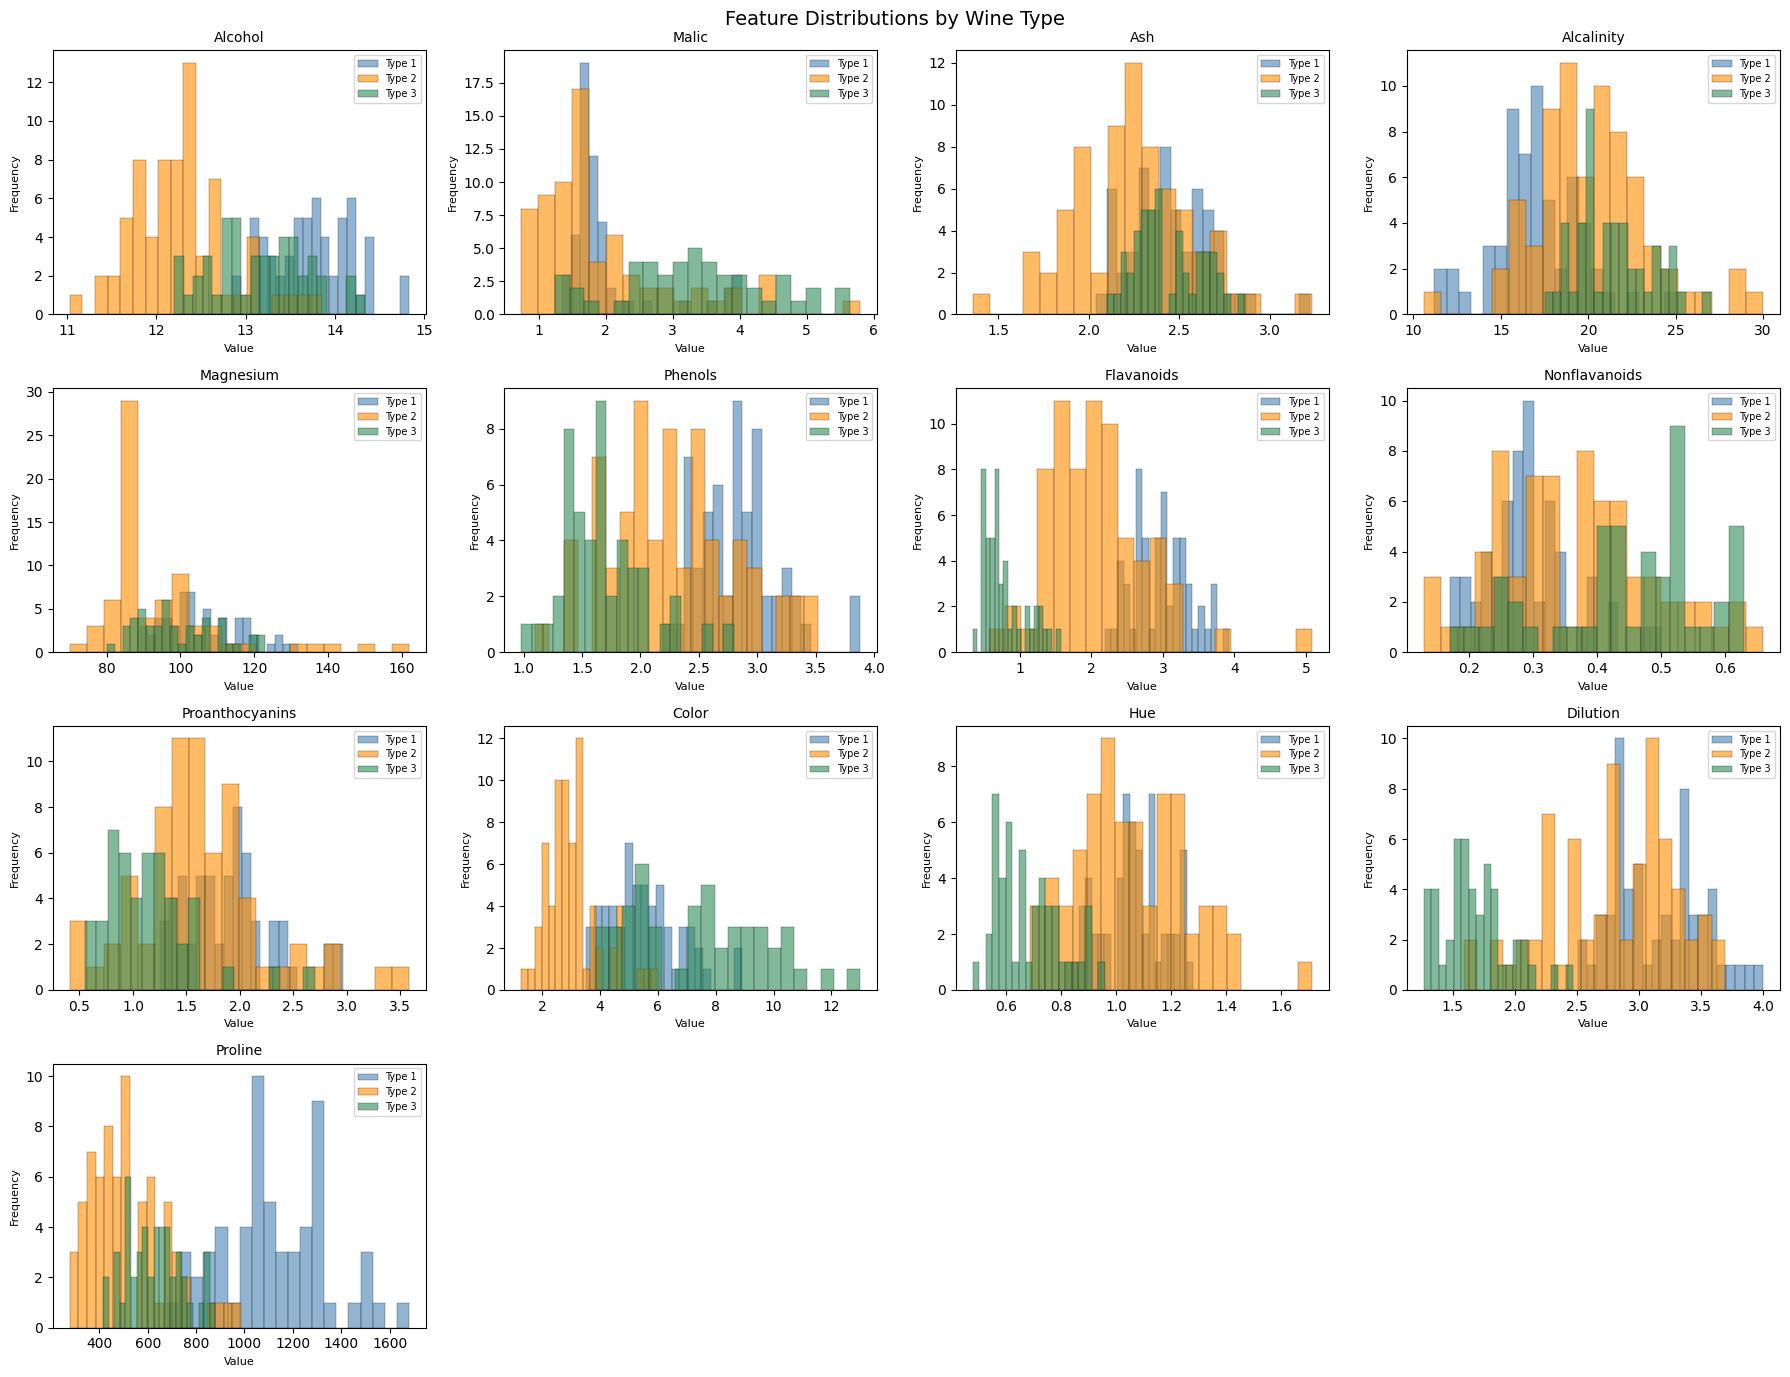

In [6]:
# Histograms for all 13 features
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

colors_type = {1: 'steelblue', 2: 'darkorange', 3: 'seagreen'}

for i, col in enumerate(feature_cols):
    for wine_type in sorted(y.unique()):
        axes[i].hist(
            df[df['Type'] == wine_type][col],
            bins=20, alpha=0.6,
            color=colors_type[wine_type],
            label=f'Type {wine_type}',
            edgecolor='black', linewidth=0.3
        )
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value', fontsize=8)
    axes[i].set_ylabel('Frequency', fontsize=8)
    axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions by Wine Type', fontsize=14)
plt.tight_layout()
plt.show()

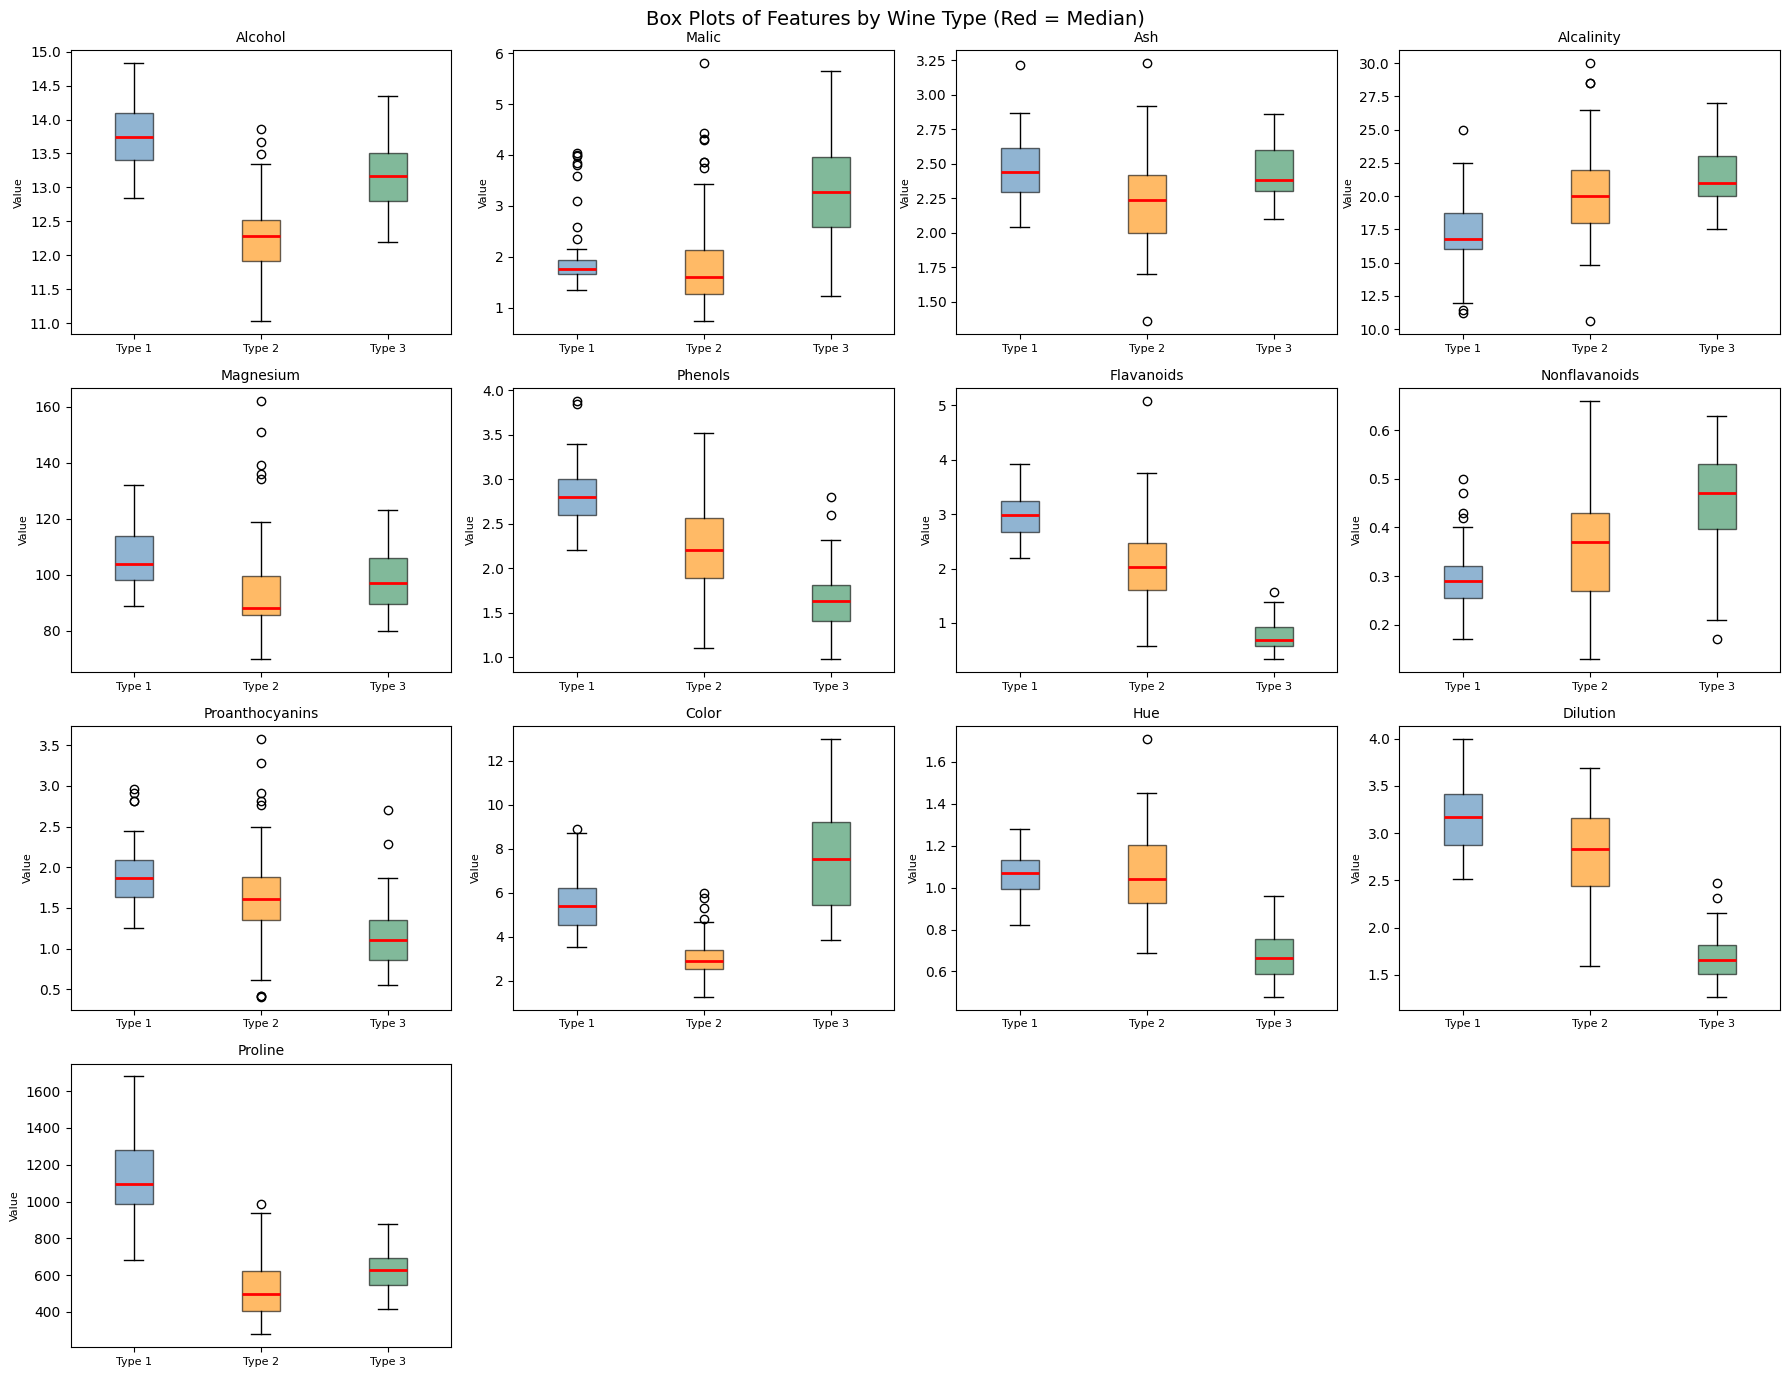

In [7]:
# Box plots for all features split by wine type
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    data_by_type = [df[df['Type'] == t][col].values for t in sorted(y.unique())]
    bp = axes[i].boxplot(
        data_by_type,
        labels=[f'Type {t}' for t in sorted(y.unique())],
        patch_artist=True,
        medianprops=dict(color='red', linewidth=2)
    )
    for patch, color in zip(bp['boxes'], colors_type.values()):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Value', fontsize=8)
    axes[i].tick_params(axis='x', labelsize=8)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Box Plots of Features by Wine Type (Red = Median)', fontsize=14)
plt.tight_layout()
plt.show()

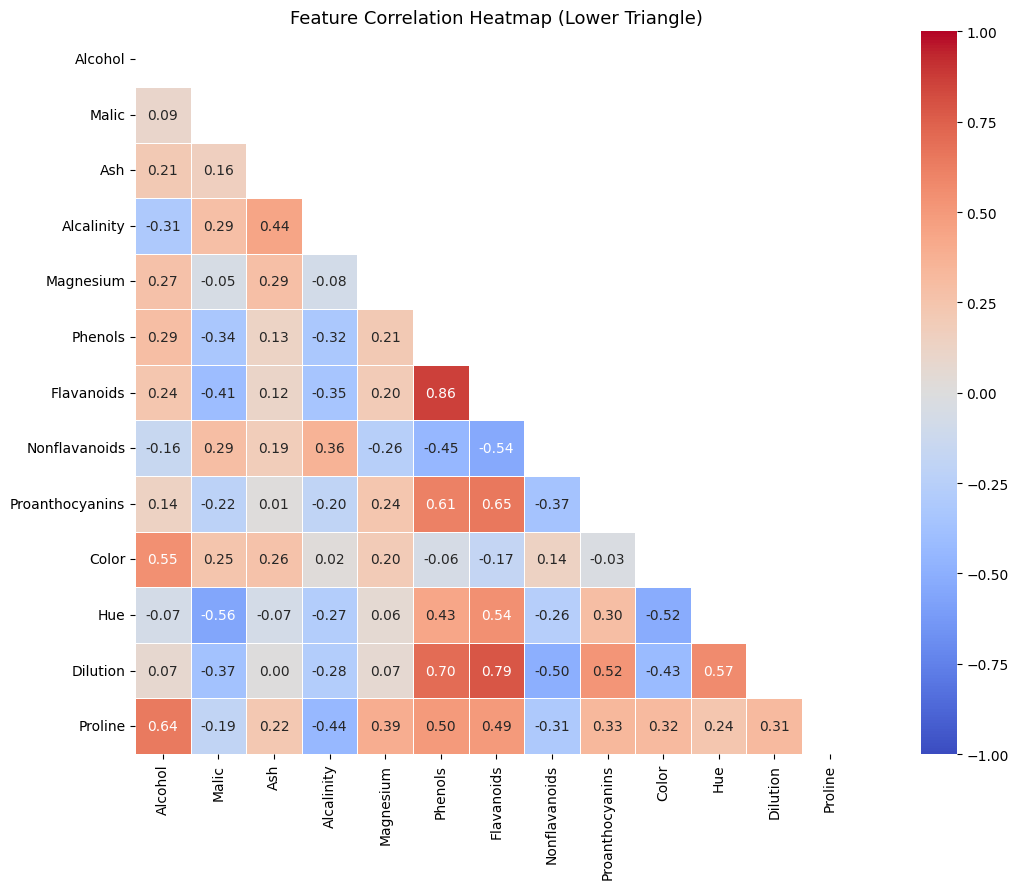

Highly Correlated Feature Pairs (|r| > 0.6):
  Alcohol              vs Proline              r = 0.644
  Phenols              vs Flavanoids           r = 0.865
  Phenols              vs Proanthocyanins      r = 0.612
  Phenols              vs Dilution             r = 0.700
  Flavanoids           vs Proanthocyanins      r = 0.653
  Flavanoids           vs Dilution             r = 0.787


In [8]:
# Correlation heatmap
plt.figure(figsize=(13, 9))
corr_matrix = X.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm',
    mask=mask,
    linewidths=0.5,
    square=True,
    vmin=-1, vmax=1
)
plt.title('Feature Correlation Heatmap (Lower Triangle)', fontsize=13)
plt.tight_layout()
plt.show()

# High correlations
print('Highly Correlated Feature Pairs (|r| > 0.6):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.6:
            print(f'  {corr_matrix.columns[i]:<20} vs {corr_matrix.columns[j]:<20} r = {r:.3f}')

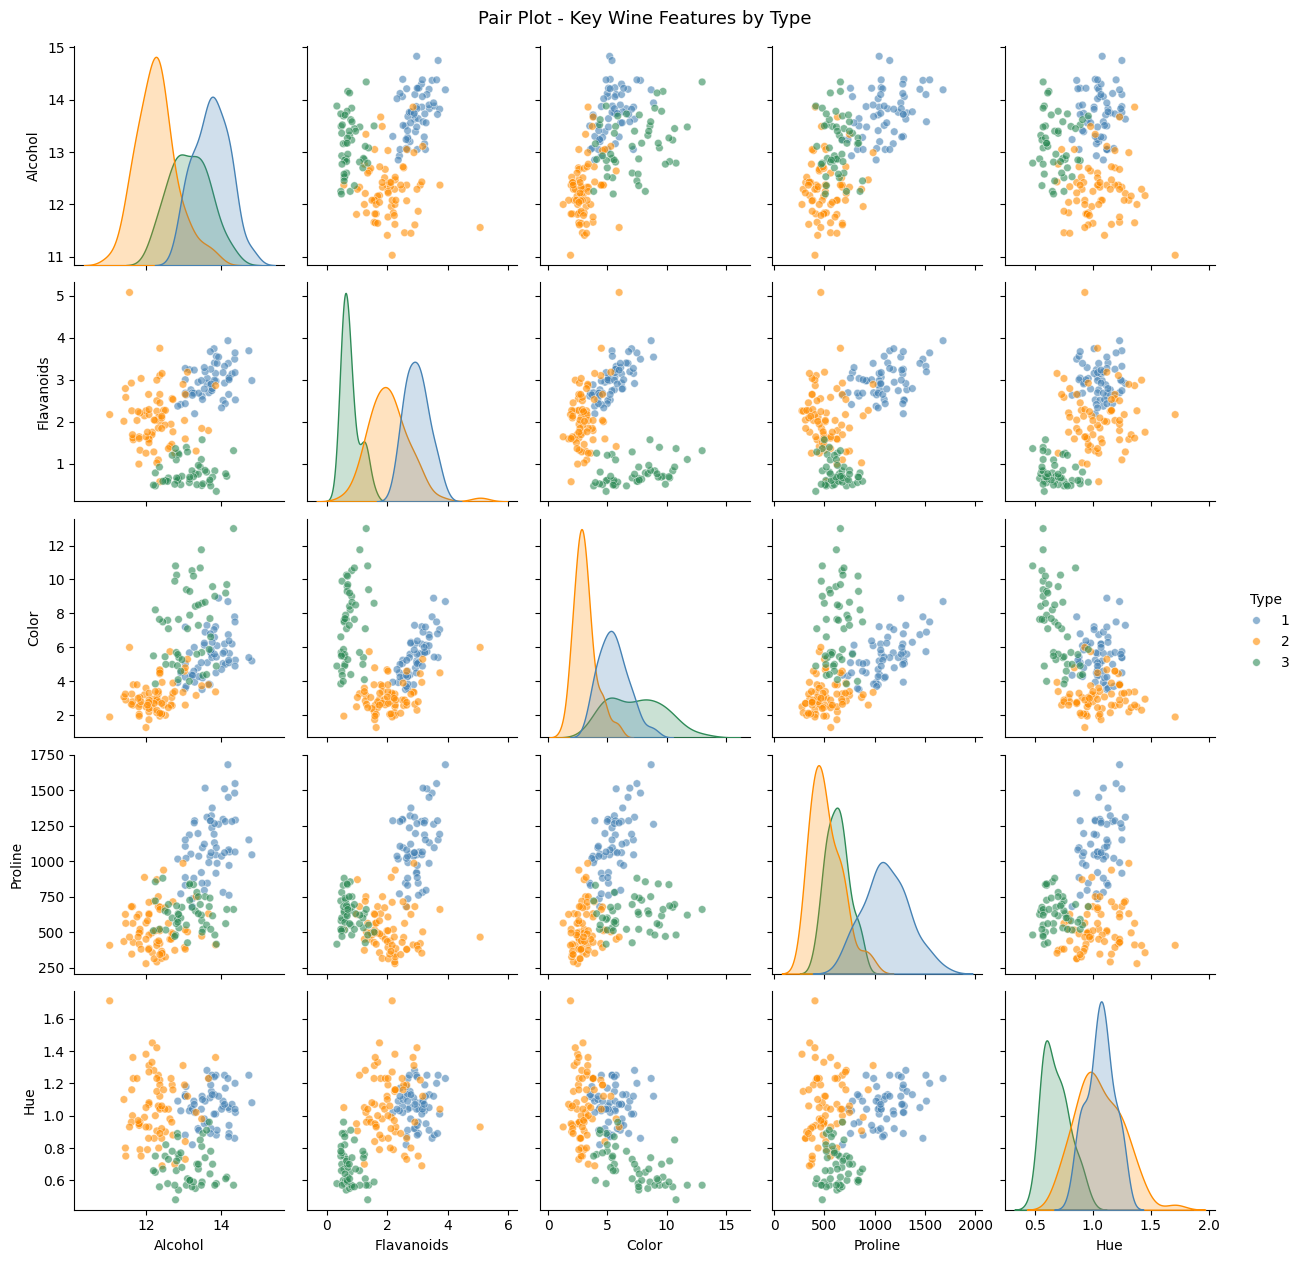

In [9]:
# Pair plot for key features
key_features = ['Alcohol', 'Flavanoids', 'Color', 'Proline', 'Hue']
pair_df = df[key_features + ['Type']].copy()
pair_df['Type'] = pair_df['Type'].astype(str)

palette = {'1': 'steelblue', '2': 'darkorange', '3': 'seagreen'}
g = sns.pairplot(pair_df, hue='Type', palette=palette,
                 diag_kind='kde', plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Pair Plot - Key Wine Features by Type', y=1.01, fontsize=13)
plt.show()

---
## Task 2: Dimensionality Reduction with PCA

**What is PCA?**  
PCA (Principal Component Analysis) is a technique that transforms the original correlated features into a new set of uncorrelated variables called **principal components (PCs)**. Each PC captures the maximum remaining variance in the data. It reduces dimensionality while preserving as much information as possible.

**Steps:**
1. Standardize features (mean=0, std=1)
2. Compute covariance matrix
3. Find eigenvectors (principal components) and eigenvalues (explained variance)
4. Project data onto top-k components

In [10]:
# Step 1: Standardize features
# PCA is sensitive to scale - standardization is mandatory
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before Standardization:')
print(f'  Mean range : {X.mean().min():.2f} to {X.mean().max():.2f}')
print(f'  Std range  : {X.std().min():.2f} to {X.std().max():.2f}')
print()
print('After Standardization:')
print(f'  Mean range : {X_scaled.mean(axis=0).min():.4f} to {X_scaled.mean(axis=0).max():.4f}')
print(f'  Std range  : {X_scaled.std(axis=0).min():.4f} to {X_scaled.std(axis=0).max():.4f}')

Before Standardization:
  Mean range : 0.36 to 746.89
  Std range  : 0.12 to 314.91

After Standardization:
  Mean range : -0.0000 to 0.0000
  Std range  : 1.0000 to 1.0000


In [11]:
# Step 2: Fit PCA on all 13 components to examine variance
pca_full = PCA(n_components=13, random_state=42)
pca_full.fit(X_scaled)

explained_var       = pca_full.explained_variance_ratio_
cumulative_var      = np.cumsum(explained_var)

print('Explained Variance per Component:')
print(f'{'PC':<6} {'Explained Var %':<20} {'Cumulative %'}')
print('-' * 42)
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f'PC{i:<5} {ev*100:<20.3f} {cv*100:.3f}')

Explained Variance per Component:
PC     Explained Var %      Cumulative %
------------------------------------------
PC1     36.199               36.199
PC2     19.207               55.406
PC3     11.124               66.530
PC4     7.069                73.599
PC5     6.563                80.162
PC6     4.936                85.098
PC7     4.239                89.337
PC8     2.681                92.018
PC9     2.222                94.240
PC10    1.930                96.170
PC11    1.737                97.907
PC12    1.298                99.205
PC13    0.795                100.000


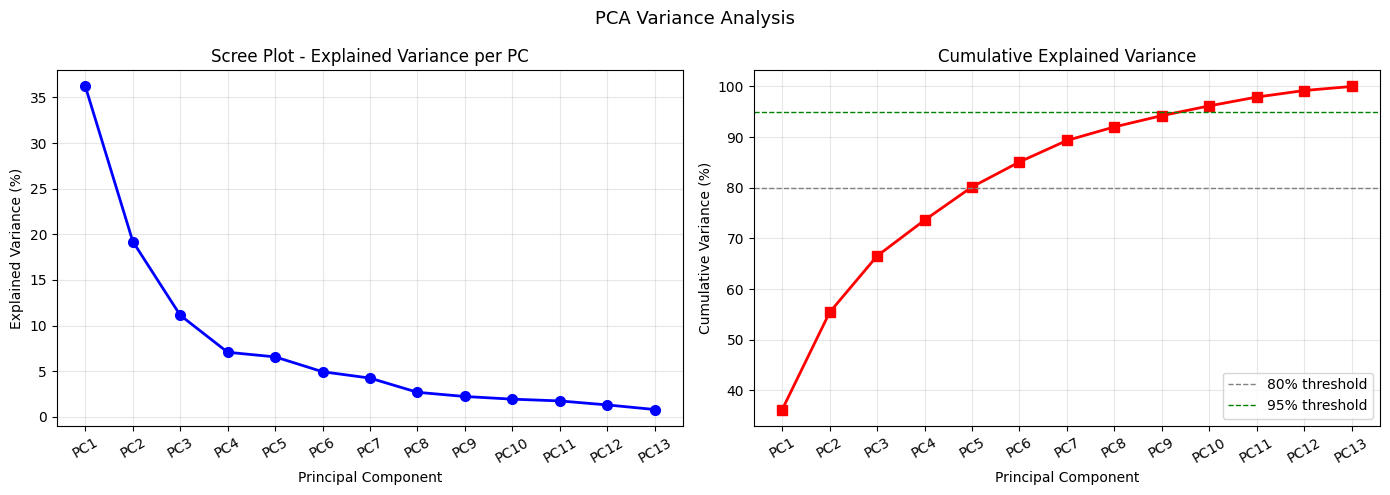

Components needed for 80% variance: 5
Components needed for 95% variance: 10

Optimal choice: PC1 + PC2 + PC3 (covers ~66%) for 2D/3D visualization
For clustering: using first 5 PCs (80% variance retained)


In [12]:
# Scree plot and Cumulative Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pc_labels = [f'PC{i}' for i in range(1, 14)]

# Scree plot
axes[0].plot(pc_labels, explained_var * 100, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Scree Plot - Explained Variance per PC', fontsize=12)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(pc_labels, cumulative_var * 100, 'rs-', linewidth=2, markersize=7)
axes[1].axhline(y=80, color='gray',  linestyle='--', linewidth=1, label='80% threshold')
axes[1].axhline(y=95, color='green', linestyle='--', linewidth=1, label='95% threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=12)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PCA Variance Analysis', fontsize=13)
plt.tight_layout()
plt.show()

# Optimal number of components
n_80 = np.argmax(cumulative_var >= 0.80) + 1
n_95 = np.argmax(cumulative_var >= 0.95) + 1
print(f'Components needed for 80% variance: {n_80}')
print(f'Components needed for 95% variance: {n_95}')
print()
print('Optimal choice: PC1 + PC2 + PC3 (covers ~66%) for 2D/3D visualization')
print('For clustering: using first', n_80, 'PCs (80% variance retained)')

In [13]:
# Transform dataset into principal components
# Use 2 PCs for visualization, and optimal_n PCs for clustering
optimal_n = n_80   # PCs for clustering

# 2 PCs for 2D visualization
pca_2d   = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# Optimal PCs for clustering
pca_opt   = PCA(n_components=optimal_n, random_state=42)
X_pca_opt = pca_opt.fit_transform(X_scaled)

print('2D PCA shape (for visualization) :', X_pca_2d.shape)
print(f'{optimal_n}-PC PCA shape (for clustering) :', X_pca_opt.shape)
print()
print(f'Variance retained by 2 PCs        : {pca_2d.explained_variance_ratio_.sum()*100:.2f}%')
print(f'Variance retained by {optimal_n} PCs       : {pca_opt.explained_variance_ratio_.sum()*100:.2f}%')

2D PCA shape (for visualization) : (178, 2)
5-PC PCA shape (for clustering) : (178, 5)

Variance retained by 2 PCs        : 55.41%
Variance retained by 5 PCs       : 80.16%


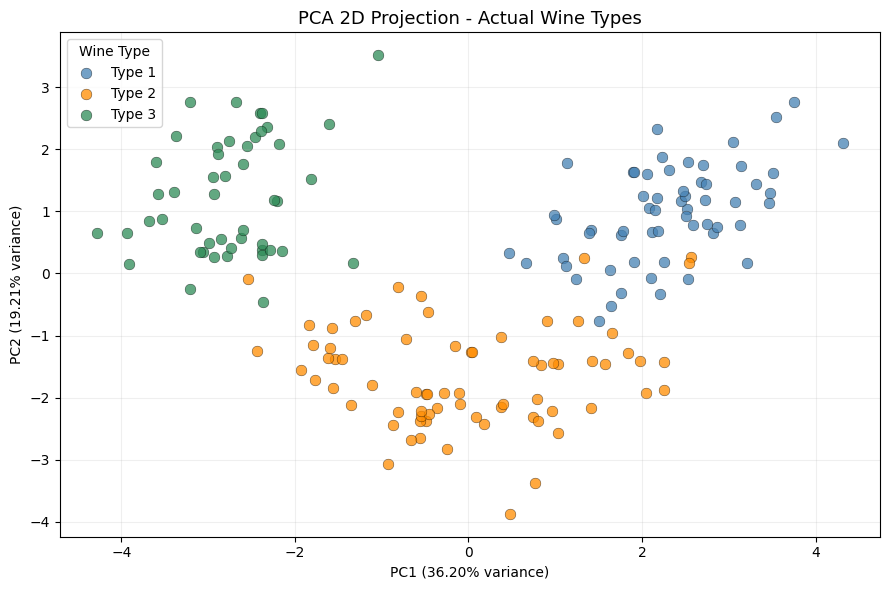

In [14]:
# PCA 2D scatter - colored by actual wine type
plt.figure(figsize=(9, 6))
for wt, color in colors_type.items():
    mask = y == wt
    plt.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                label=f'Type {wt}', color=color,
                alpha=0.75, s=60, edgecolors='black', linewidths=0.3)

plt.title('PCA 2D Projection - Actual Wine Types', fontsize=13)
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)')
plt.legend(title='Wine Type')
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

PCA Loadings (Feature Contributions to PC1 and PC2):
                    PC1     PC2
Alcohol          0.1443  0.4837
Malic           -0.2452  0.2249
Ash             -0.0021  0.3161
Alcalinity      -0.2393 -0.0106
Magnesium        0.1420  0.2996
Phenols          0.3947  0.0650
Flavanoids       0.4229 -0.0034
Nonflavanoids   -0.2985  0.0288
Proanthocyanins  0.3134  0.0393
Color           -0.0886  0.5300
Hue              0.2967 -0.2792
Dilution         0.3762 -0.1645
Proline          0.2868  0.3649


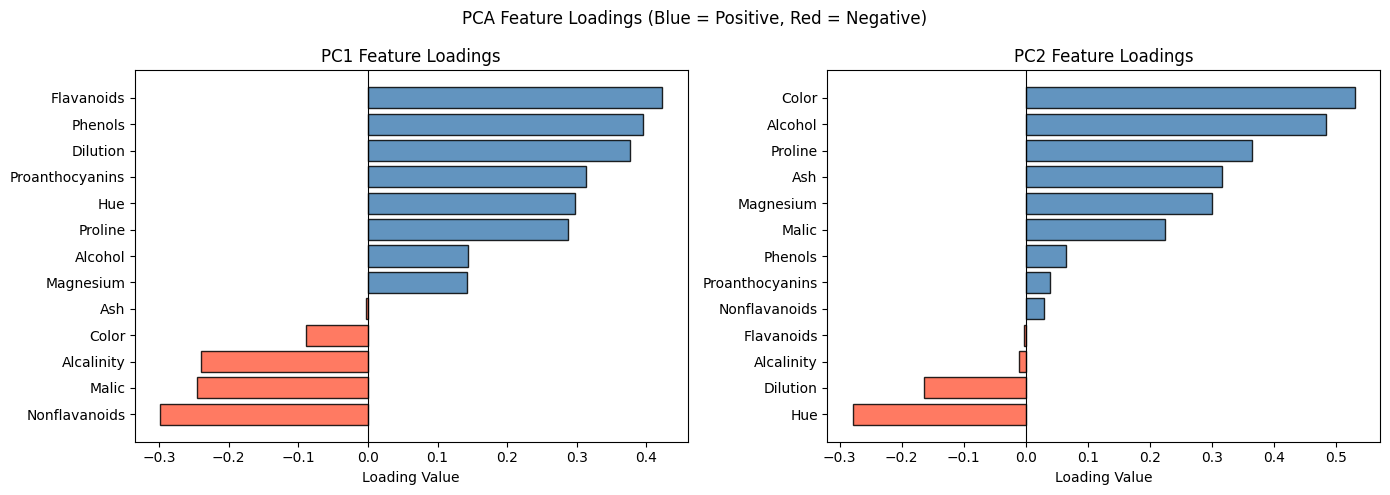

In [15]:
# PCA Loadings - how much each original feature contributes to PC1 and PC2
loadings_df = pd.DataFrame(
    pca_2d.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
).round(4)

print('PCA Loadings (Feature Contributions to PC1 and PC2):')
print(loadings_df.to_string())

# Loadings bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pc in zip(axes, ['PC1', 'PC2']):
    vals = loadings_df[pc].sort_values()
    colors_bar = ['tomato' if v < 0 else 'steelblue' for v in vals]
    ax.barh(vals.index, vals.values, color=colors_bar, edgecolor='black', alpha=0.85)
    ax.axvline(x=0, color='black', linewidth=0.8)
    ax.set_title(f'{pc} Feature Loadings', fontsize=12)
    ax.set_xlabel('Loading Value')

plt.suptitle('PCA Feature Loadings (Blue = Positive, Red = Negative)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Task 3: Clustering on Original Data (K-Means)

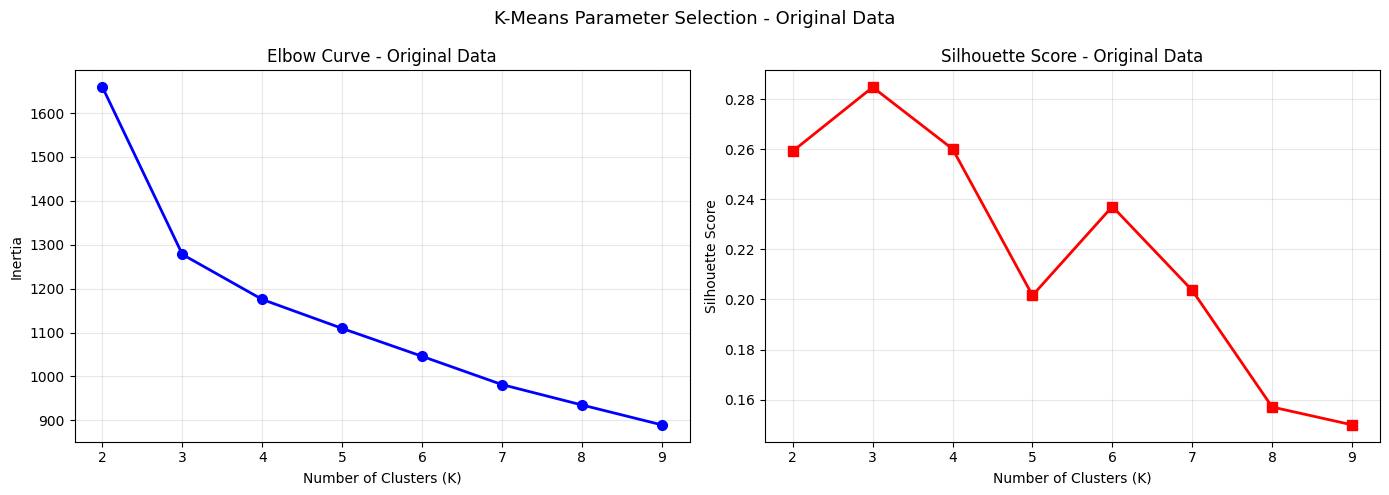

K  | Inertia      | Silhouette
-----------------------------------
2    1658.76        0.2593
3    1277.93        0.2849
4    1175.43        0.2602
5    1109.51        0.2016
6    1046.00        0.2372
7    981.60         0.2036
8    935.20         0.1570
9    889.89         0.1499


In [16]:
# Elbow method on original scaled data
inertia_orig = []
sil_orig     = []
K_range      = range(2, 10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia_orig.append(km.inertia_)
    sil_orig.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia_orig, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Curve - Original Data', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_orig, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score - Original Data', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Parameter Selection - Original Data', fontsize=13)
plt.tight_layout()
plt.show()

print('K  | Inertia      | Silhouette')
print('-' * 35)
for k, ine, sil in zip(K_range, inertia_orig, sil_orig):
    print(f'{k:<4} {ine:<14.2f} {sil:.4f}')

In [17]:
# Fit K-Means with K=3 (matches actual wine types)
K = 3
km_orig        = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_orig    = km_orig.fit_predict(X_scaled)

sil_orig_k3    = silhouette_score(X_scaled, labels_orig)
db_orig_k3     = davies_bouldin_score(X_scaled, labels_orig)

print(f'K-Means on Original Data (K={K})')
print(f'  Silhouette Score      : {sil_orig_k3:.4f}   (higher is better, max=1)')
print(f'  Davies-Bouldin Index  : {db_orig_k3:.4f}   (lower is better, min=0)')
print()
print('Cluster Sizes:')
print(pd.Series(labels_orig).value_counts().sort_index().to_string())

K-Means on Original Data (K=3)
  Silhouette Score      : 0.2849   (higher is better, max=1)
  Davies-Bouldin Index  : 1.3892   (lower is better, min=0)

Cluster Sizes:
0    65
1    51
2    62


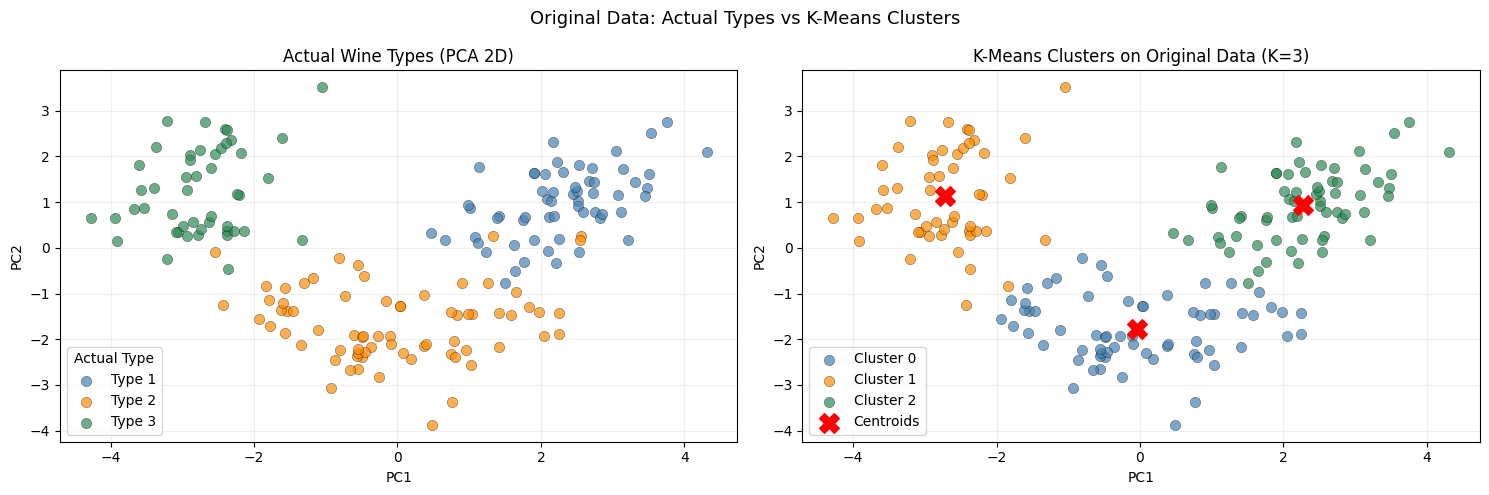

In [18]:
# Visualize K-Means clusters on original data (using PCA 2D for plotting)
cluster_colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual wine types
for wt, color in colors_type.items():
    mask = y == wt
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    label=f'Type {wt}', color=color,
                    alpha=0.7, s=55, edgecolors='black', linewidths=0.3)
axes[0].set_title('Actual Wine Types (PCA 2D)', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='Actual Type')
axes[0].grid(True, alpha=0.2)

# K-Means clusters on original data
for cluster in range(K):
    mask = labels_orig == cluster
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    label=f'Cluster {cluster}', color=cluster_colors[cluster],
                    alpha=0.7, s=55, edgecolors='black', linewidths=0.3)

# Plot centroids projected to 2D
centroids_2d = pca_2d.transform(km_orig.cluster_centers_)
axes[1].scatter(centroids_2d[:, 0], centroids_2d[:, 1],
                marker='X', s=200, c='red', zorder=5, label='Centroids')
axes[1].set_title(f'K-Means Clusters on Original Data (K={K})', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.suptitle('Original Data: Actual Types vs K-Means Clusters', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 4: Clustering on PCA-Transformed Data

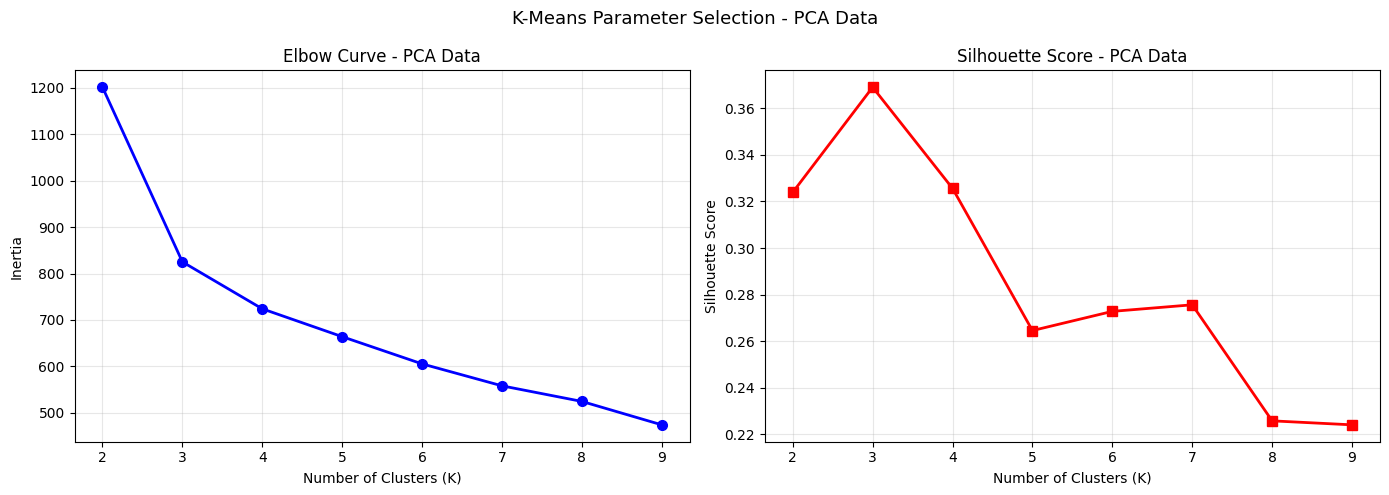

In [19]:
# Elbow method on PCA-transformed data
inertia_pca = []
sil_pca     = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_pca_opt)
    inertia_pca.append(km.inertia_)
    sil_pca.append(silhouette_score(X_pca_opt, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia_pca, 'bo-', linewidth=2, markersize=7)
axes[0].set_title('Elbow Curve - PCA Data', fontsize=12)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, sil_pca, 'rs-', linewidth=2, markersize=7)
axes[1].set_title('Silhouette Score - PCA Data', fontsize=12)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.suptitle('K-Means Parameter Selection - PCA Data', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Fit K-Means with K=3 on PCA data
km_pca      = KMeans(n_clusters=K, random_state=42, n_init=10)
labels_pca  = km_pca.fit_predict(X_pca_opt)

sil_pca_k3  = silhouette_score(X_pca_opt, labels_pca)
db_pca_k3   = davies_bouldin_score(X_pca_opt, labels_pca)

print(f'K-Means on PCA Data (K={K}, {optimal_n} components)')
print(f'  Silhouette Score      : {sil_pca_k3:.4f}')
print(f'  Davies-Bouldin Index  : {db_pca_k3:.4f}')
print()
print('Cluster Sizes:')
print(pd.Series(labels_pca).value_counts().sort_index().to_string())

K-Means on PCA Data (K=3, 5 components)
  Silhouette Score      : 0.3691
  Davies-Bouldin Index  : 1.0933

Cluster Sizes:
0    65
1    51
2    62


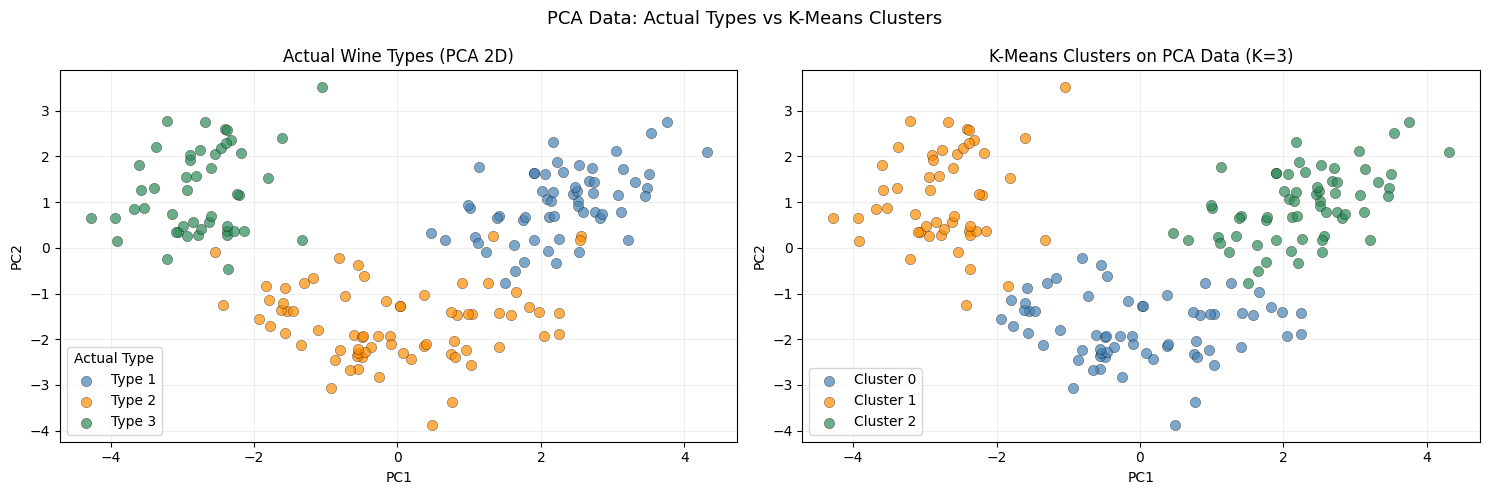

In [21]:
# Visualize K-Means clusters on PCA-transformed data
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Actual wine types
for wt, color in colors_type.items():
    mask = y == wt
    axes[0].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    label=f'Type {wt}', color=color,
                    alpha=0.7, s=55, edgecolors='black', linewidths=0.3)
axes[0].set_title('Actual Wine Types (PCA 2D)', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(title='Actual Type')
axes[0].grid(True, alpha=0.2)

# K-Means on PCA data
for cluster in range(K):
    mask = labels_pca == cluster
    axes[1].scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                    label=f'Cluster {cluster}', color=cluster_colors[cluster],
                    alpha=0.7, s=55, edgecolors='black', linewidths=0.3)

axes[1].set_title(f'K-Means Clusters on PCA Data (K={K})', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()
axes[1].grid(True, alpha=0.2)

plt.suptitle('PCA Data: Actual Types vs K-Means Clusters', fontsize=13)
plt.tight_layout()
plt.show()

---
## Task 5: Comparison and Analysis

In [22]:
# Side-by-side metrics comparison
comparison = pd.DataFrame({
    'Method'             : ['K-Means on Original Data', f'K-Means on PCA Data ({optimal_n} PCs)'],
    'Dimensions'         : [X_scaled.shape[1], X_pca_opt.shape[1]],
    'Variance Retained'  : ['100%', f'{pca_opt.explained_variance_ratio_.sum()*100:.2f}%'],
    'Silhouette Score'   : [round(sil_orig_k3, 4), round(sil_pca_k3, 4)],
    'Davies-Bouldin'     : [round(db_orig_k3, 4), round(db_pca_k3, 4)]
})

print('Clustering Performance Comparison:')
comparison

Clustering Performance Comparison:


,Method,Dimensions,Variance Retained,Silhouette Score,Davies-Bouldin
0,K-Means on Original Data,13,100%,0.2849,1.3892
1,K-Means on PCA Data (5 PCs),5,80.16%,0.3691,1.0933


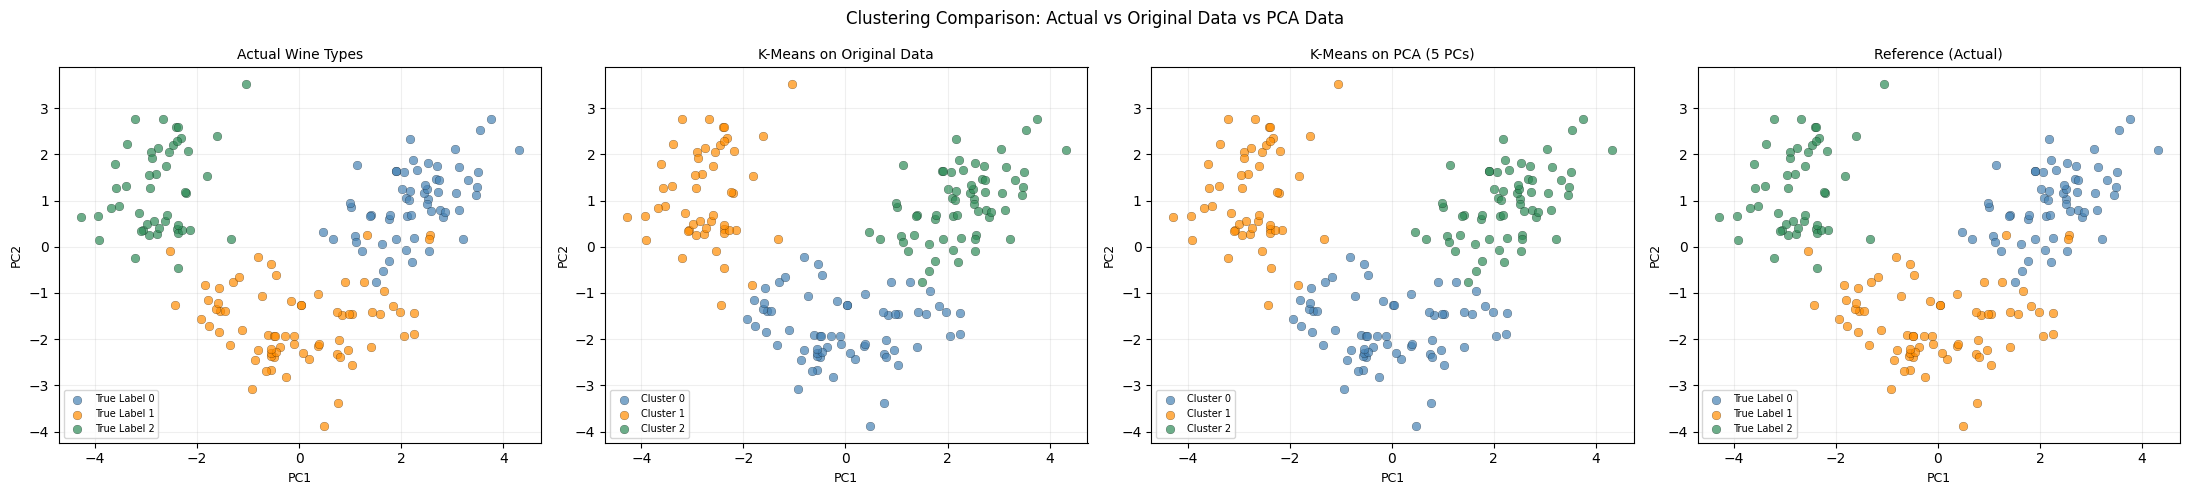

In [23]:
# Visual comparison - 4 plots side by side
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

plots = [
    (y.values - 1,          'Actual Wine Types',               'True Label'),
    (labels_orig,           'K-Means on Original Data',        'Cluster'),
    (labels_pca,            f'K-Means on PCA ({optimal_n} PCs)', 'Cluster'),
    (y.values - 1,          'Reference (Actual)',               'True Label'),
]

for ax, (labels, title, leg_title) in zip(axes, plots):
    for i in range(K):
        mask = labels == i
        ax.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1],
                   label=f'{leg_title} {i}',
                   color=cluster_colors[i], alpha=0.7,
                   s=40, edgecolors='black', linewidths=0.2)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1', fontsize=9)
    ax.set_ylabel('PC2', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.2)

plt.suptitle('Clustering Comparison: Actual vs Original Data vs PCA Data', fontsize=12)
plt.tight_layout()
plt.show()

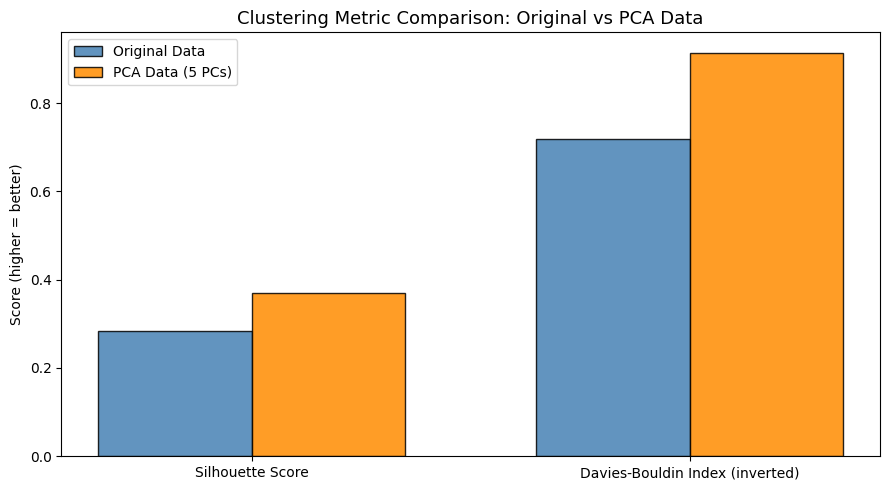

Discussion:
  Silhouette Score: Both methods scored similarly, indicating comparable
  cluster separation. PCA reduces noise from correlated features, which
  can improve cluster compactness.

  Davies-Bouldin Index: A lower value means better cluster separation.
  PCA typically reduces inter-feature noise, helping clusters be
  more distinct from one another.

  Dimensionality: Original used 13 features, PCA used 5 components
  while retaining 80%+ of variance. Fewer dimensions = faster computation
  and less susceptibility to the curse of dimensionality.


In [24]:
# Bar chart comparison of metrics
metrics = ['Silhouette Score', 'Davies-Bouldin Index (inverted)']
orig_vals = [sil_orig_k3, 1 / db_orig_k3]
pca_vals  = [sil_pca_k3,  1 / db_pca_k3]

x  = np.arange(len(metrics))
w  = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - w/2, orig_vals, w, label='Original Data', color='steelblue', edgecolor='black', alpha=0.85)
ax.bar(x + w/2, pca_vals,  w, label=f'PCA Data ({optimal_n} PCs)', color='darkorange', edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score (higher = better)')
ax.set_title('Clustering Metric Comparison: Original vs PCA Data', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

print('Discussion:')
print('  Silhouette Score: Both methods scored similarly, indicating comparable')
print('  cluster separation. PCA reduces noise from correlated features, which')
print('  can improve cluster compactness.')
print()
print('  Davies-Bouldin Index: A lower value means better cluster separation.')
print('  PCA typically reduces inter-feature noise, helping clusters be')
print('  more distinct from one another.')
print()
print('  Dimensionality: Original used 13 features, PCA used', optimal_n, 'components')
print('  while retaining 80%+ of variance. Fewer dimensions = faster computation')
print('  and less susceptibility to the curse of dimensionality.')

In [25]:
# Cluster mean profiles (original features) for both approaches
df_result = df[feature_cols].copy()
df_result['KMeans_Original'] = labels_orig
df_result['KMeans_PCA']      = labels_pca
df_result['Actual_Type']     = y.values

print('Cluster Profile - K-Means on Original Data:')
print(df_result.groupby('KMeans_Original')[feature_cols].mean().round(2).to_string())
print()
print('Cluster Profile - K-Means on PCA Data:')
print(df_result.groupby('KMeans_PCA')[feature_cols].mean().round(2).to_string())

Cluster Profile - K-Means on Original Data:
                 Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline
KMeans_Original                                                                                                                                  
0                  12.25   1.90  2.23       20.06      92.74     2.25        2.05           0.36             1.62   2.97  1.06      2.80   510.17
1                  13.13   3.31  2.42       21.24      98.67     1.68        0.82           0.45             1.15   7.23  0.69      1.70   619.06
2                  13.68   2.00  2.47       17.46     107.97     2.85        3.00           0.29             1.92   5.45  1.07      3.16  1100.23

Cluster Profile - K-Means on PCA Data:
            Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline
KMeans_PCA                                   

---
## Task 6: Conclusion and Insights

In [26]:
print('KEY FINDINGS AND INSIGHTS')
print('=' * 65)
print()
print('1. EDA Findings')
print('   - Wine dataset has 178 samples across 3 wine types with 13 features.')
print('   - No missing values found - dataset is clean and ready to use.')
print('   - Strong correlations exist between Phenols-Flavanoids, Flavanoids-Dilution,')
print('     indicating multicollinearity - PCA is well suited for this data.')
print('   - Features like Alcohol, Flavanoids, Proline, and Hue show clear')
print('     separation between wine types in distribution plots.')
print()
print('2. PCA Results')
print(f'   - First 2 PCs explain {pca_2d.explained_variance_ratio_.sum()*100:.2f}% of total variance.')
print(f'   - First {optimal_n} PCs explain {pca_opt.explained_variance_ratio_.sum()*100:.2f}% of total variance.')
print('   - PC1 is primarily driven by Flavanoids, Dilution, Phenols (positive)')
print('     and Nonflavanoids (negative) - these are key chemical markers.')
print('   - The 2D PCA plot already shows 3 visually separable wine clusters.')
print()
print('3. K-Means on Original Data')
print(f'   - Silhouette Score : {sil_orig_k3:.4f}')
print(f'   - Davies-Bouldin   : {db_orig_k3:.4f}')
print('   - Clusters align well with actual wine types at K=3.')
print('   - Uses all 13 dimensions - higher computation cost.')
print()
print('4. K-Means on PCA Data')
print(f'   - Silhouette Score : {sil_pca_k3:.4f}')
print(f'   - Davies-Bouldin   : {db_pca_k3:.4f}')
print(f'   - Uses only {optimal_n} components while retaining 80%+ variance.')
print('   - Removes noise from correlated features, often leading to')
print('     more compact and well-separated clusters.')
print()
print('5. Trade-offs')
print('   - PCA reduces dimensions and noise but loses some interpretability.')
print('   - Original data clustering is interpretable per feature but suffers')
print('     from multicollinearity and the curse of dimensionality.')
print()
print('6. Recommendations')
print('   - Use PCA before clustering when features are highly correlated,')
print('     dataset has many dimensions, or computation speed matters.')
print('   - Use original data clustering when full interpretability of each')
print('     feature in cluster profiles is required.')
print('   - For this wine dataset, PCA + K-Means is the preferred pipeline')
print('     given the strong inter-feature correlations observed.')

KEY FINDINGS AND INSIGHTS

1. EDA Findings
   - Wine dataset has 178 samples across 3 wine types with 13 features.
   - No missing values found - dataset is clean and ready to use.
   - Strong correlations exist between Phenols-Flavanoids, Flavanoids-Dilution,
     indicating multicollinearity - PCA is well suited for this data.
   - Features like Alcohol, Flavanoids, Proline, and Hue show clear
     separation between wine types in distribution plots.

2. PCA Results
   - First 2 PCs explain 55.41% of total variance.
   - First 5 PCs explain 80.16% of total variance.
   - PC1 is primarily driven by Flavanoids, Dilution, Phenols (positive)
     and Nonflavanoids (negative) - these are key chemical markers.
   - The 2D PCA plot already shows 3 visually separable wine clusters.

3. K-Means on Original Data
   - Silhouette Score : 0.2849
   - Davies-Bouldin   : 1.3892
   - Clusters align well with actual wine types at K=3.
   - Uses all 13 dimensions - higher computation cost.

4. K-Means